In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go # Para gráficos interactivos
import missingno as miss # Para visualizar datos faltantes
import datetime
from scipy.optimize import minimize

# Limpieza Base de Datos

La base de datos es sobre el rendimiento de tesoros de los estados unidos, 1961-06-14 hasta 2026-03-06, donde no se tienen en cuenta los fines de semana y existen datos faltantes los dias festivos o festividades importantes (como los 1 de Enero)

In [37]:
TESCOL= pd.read_csv(r"C:\\Users\\ADMON\\Documents\\Universidad\\Proyecto KMJ\\codigo\\TES_colombia\\curvas_panel_historico.csv")
TESCOL.tail()

,fecha,r_1yr,r_2yr,r_3yr,r_5yr,r_7yr,r_10yr,r_15yr,r_20yr,r_30yr
2730,2026-03-16,0.135713,0.139443,0.139828,0.139517,0.137231,0.131803,0.134240,0.132651,0.137886
2731,2026-03-17,0.128690,0.138272,0.138891,0.139341,0.135823,0.135371,0.132242,0.129399,0.135831
2732,2026-03-18,0.128653,0.139181,0.139810,0.139257,0.135137,0.129287,0.134863,0.132334,0.145189
2733,2026-03-19,0.128848,0.139770,0.140321,0.138993,0.136123,0.129225,0.134825,0.133980,0.142973
2734,2026-03-20,0.128754,0.139797,0.140673,0.139230,0.137388,0.129495,0.136129,0.134834,0.145398


In [38]:
TESCOL.columns

Index(['fecha', 'r_1yr', 'r_2yr', 'r_3yr', 'r_5yr', 'r_7yr', 'r_10yr',
       'r_15yr', 'r_20yr', 'r_30yr'],
      dtype='object')

<Axes: >

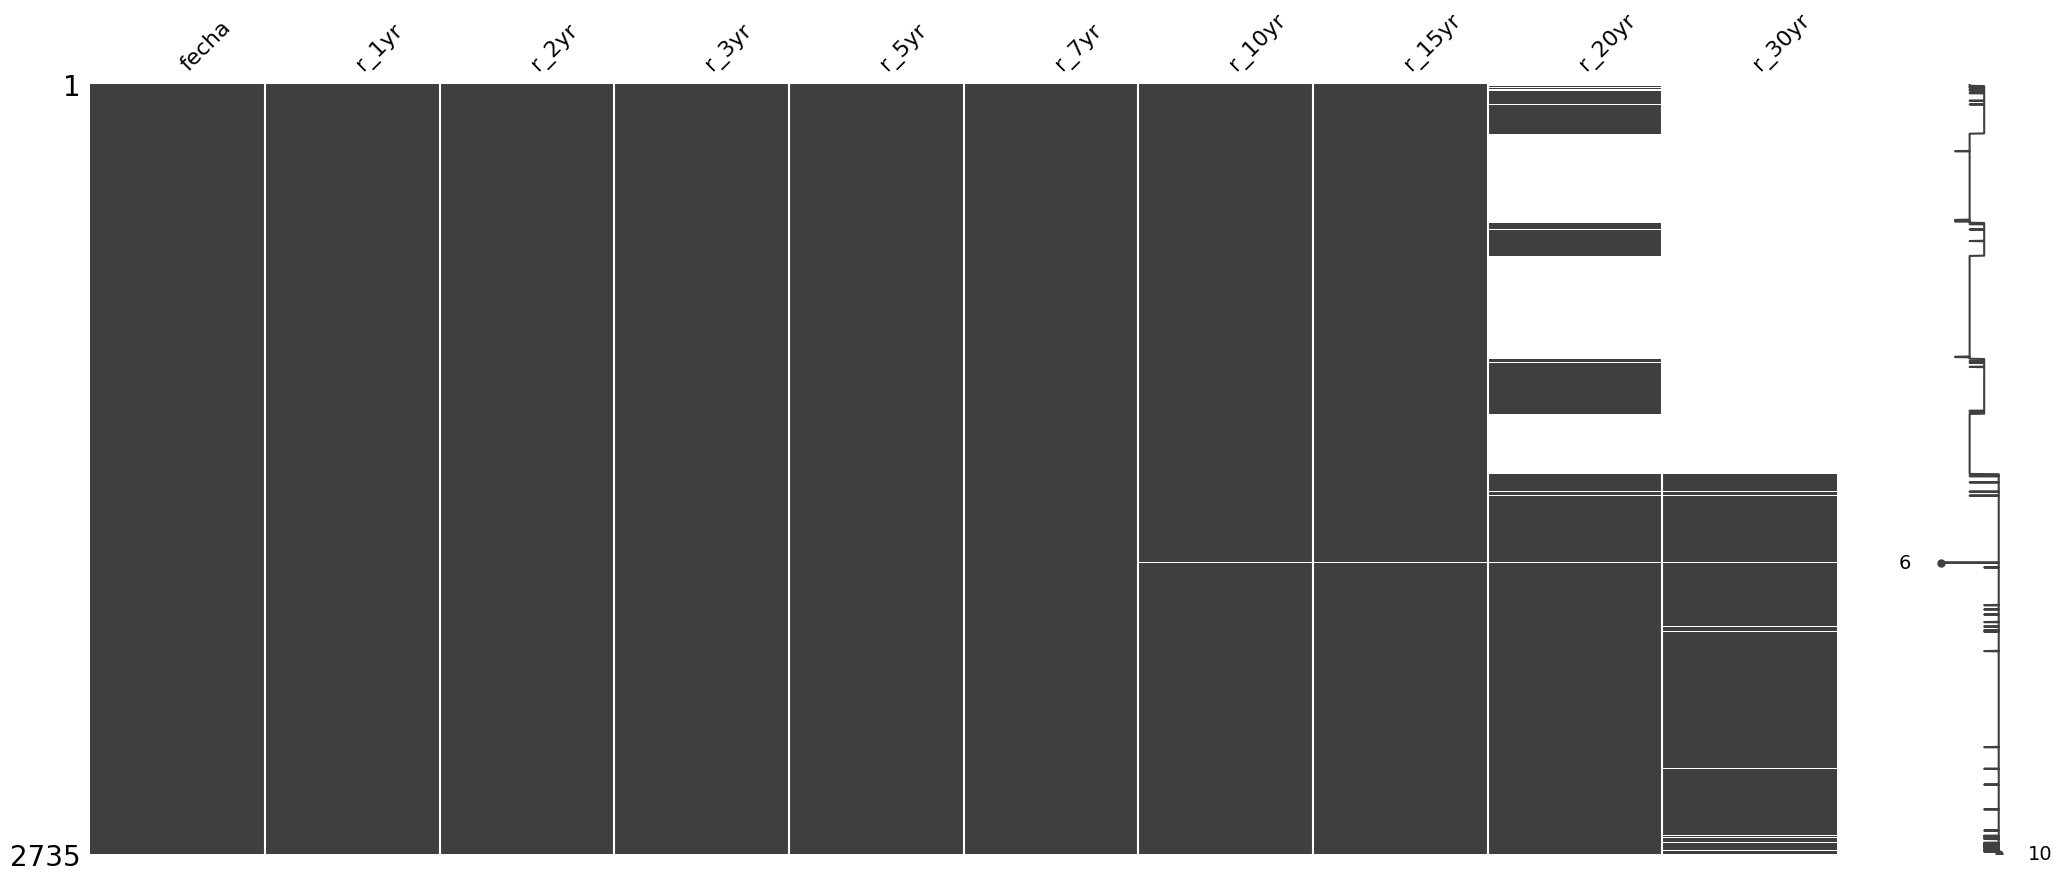

In [39]:
miss.matrix(TESCOL)

In [40]:
yield_cols = ["r_1yr", "r_2yr", "r_3yr", "r_5yr", "r_7yr", "r_10yr", "r_15yr"]
# no se toma en cuenta el r_20yr. r_30yr por la cantidad de datos faltantes
df = TESCOL[["fecha"] + yield_cols]
df[yield_cols] = df[yield_cols]*100
df

C:\Users\ADMON\AppData\Local\Temp\ipykernel_2576\3800950301.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,fecha,r_1yr,r_2yr,r_3yr,r_5yr,r_7yr,r_10yr,r_15yr
0,2015-01-02,4.914963,5.232198,5.578546,6.092016,6.908645,7.478792,8.375192
1,2015-01-05,4.909467,5.243118,5.593682,6.126808,6.956305,7.472972,8.307616
2,2015-01-06,4.907872,5.254184,5.594592,6.151343,7.000366,7.541238,8.449605
3,2015-01-07,4.856031,5.234179,5.563857,6.090384,6.892008,7.414816,8.369173
4,2015-01-08,4.818443,5.149349,5.465612,5.974379,6.781534,7.294184,8.003954
...,...,...,...,...,...,...,...,...
2730,2026-03-16,13.571282,13.944252,13.982797,13.951670,13.723108,13.180307,13.424015
2731,2026-03-17,12.868958,13.827212,13.889129,13.934115,13.582329,13.537087,13.224217
2732,2026-03-18,12.865302,13.918075,13.980974,13.925683,13.513716,12.928738,13.486307
2733,2026-03-19,12.884804,13.977047,14.032120,13.899307,13.612340,12.922455,13.482506


,fecha,r_1yr,r_2yr,r_3yr,r_5yr,r_7yr,r_10yr,r_15yr
238,2015-12-24,6.284144,6.714694,7.138405,7.778855,8.171459,8.760365,NaN
482,2016-12-23,6.002868,6.251875,6.461173,6.677749,6.894326,7.253121,NaN
483,2016-12-26,5.956351,6.217346,6.454630,6.702010,6.904135,7.207322,NaN
487,2017-01-02,6.039433,6.190140,6.340846,6.642258,6.891482,7.249455,NaN
968,2018-12-24,4.828433,5.252561,5.537332,6.070719,6.551966,7.246365,NaN
969,2018-12-26,4.841622,5.260201,5.554693,6.097502,6.607877,7.359669,NaN
1699,2021-12-24,4.336854,5.875218,7.413581,10.490309,13.567037,NaN,NaN


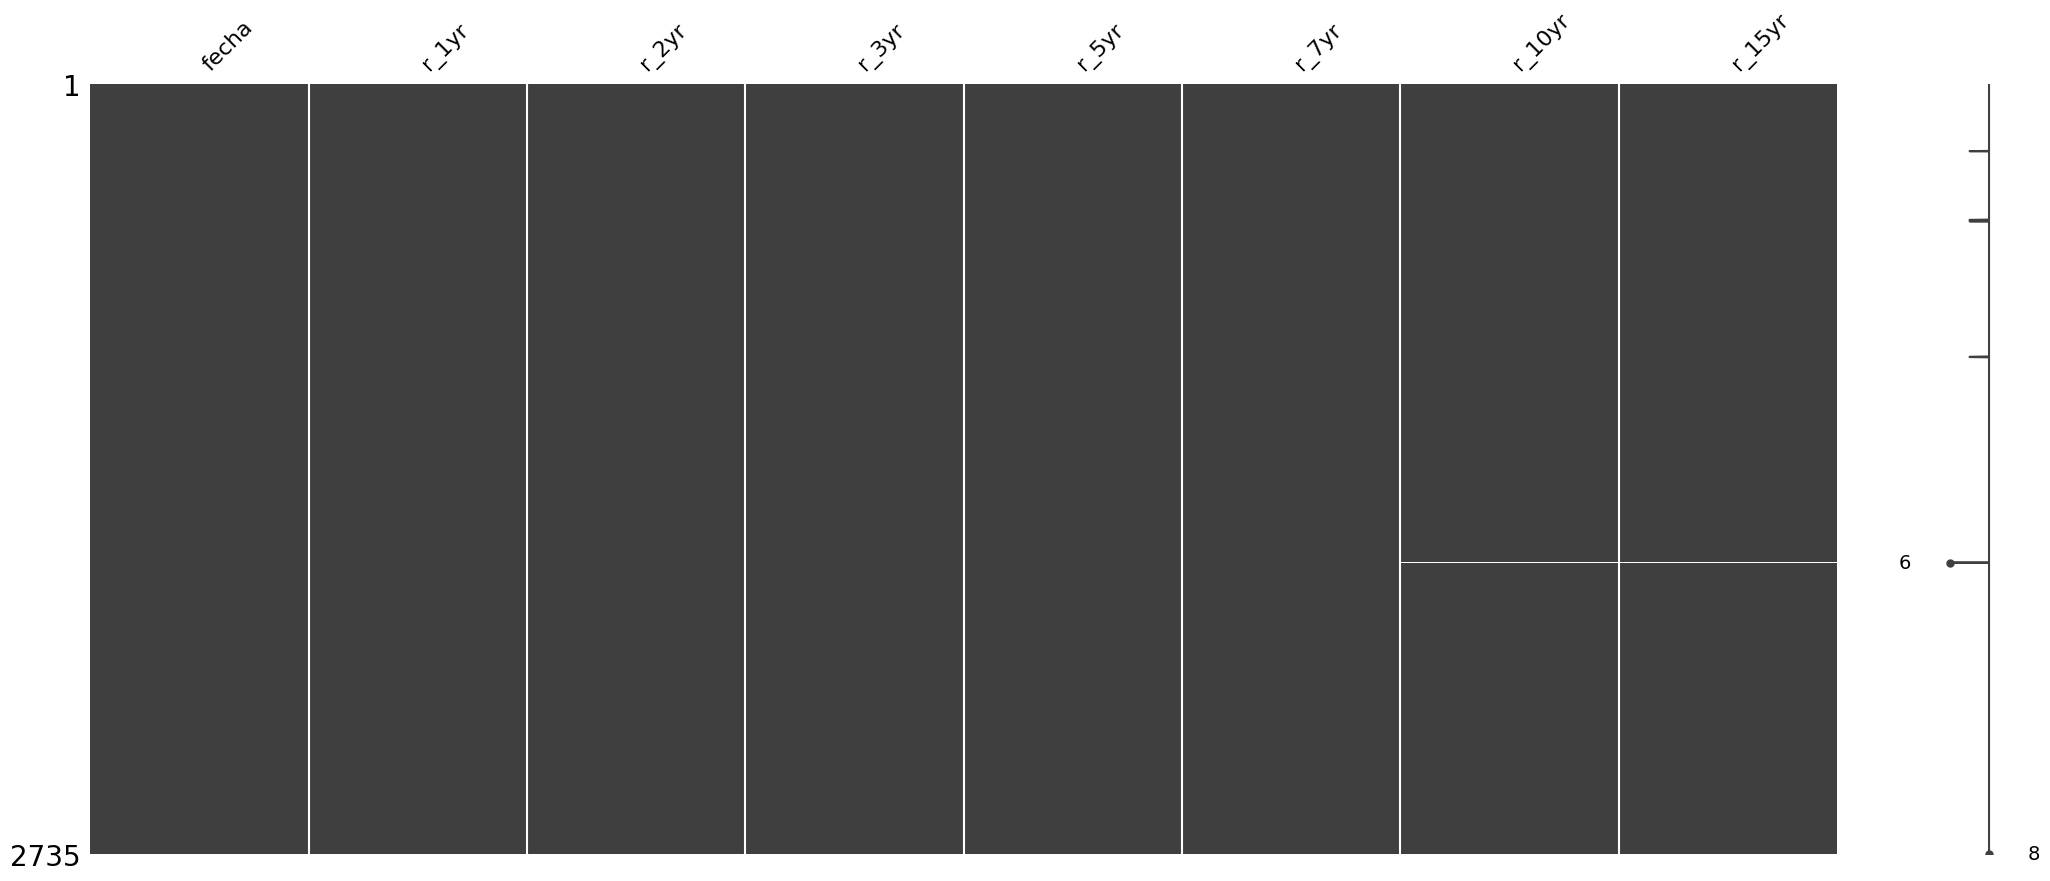

In [41]:
miss.matrix(df) 
df[df["r_10yr"].isna() | df["r_15yr"].isna()]

<Axes: >

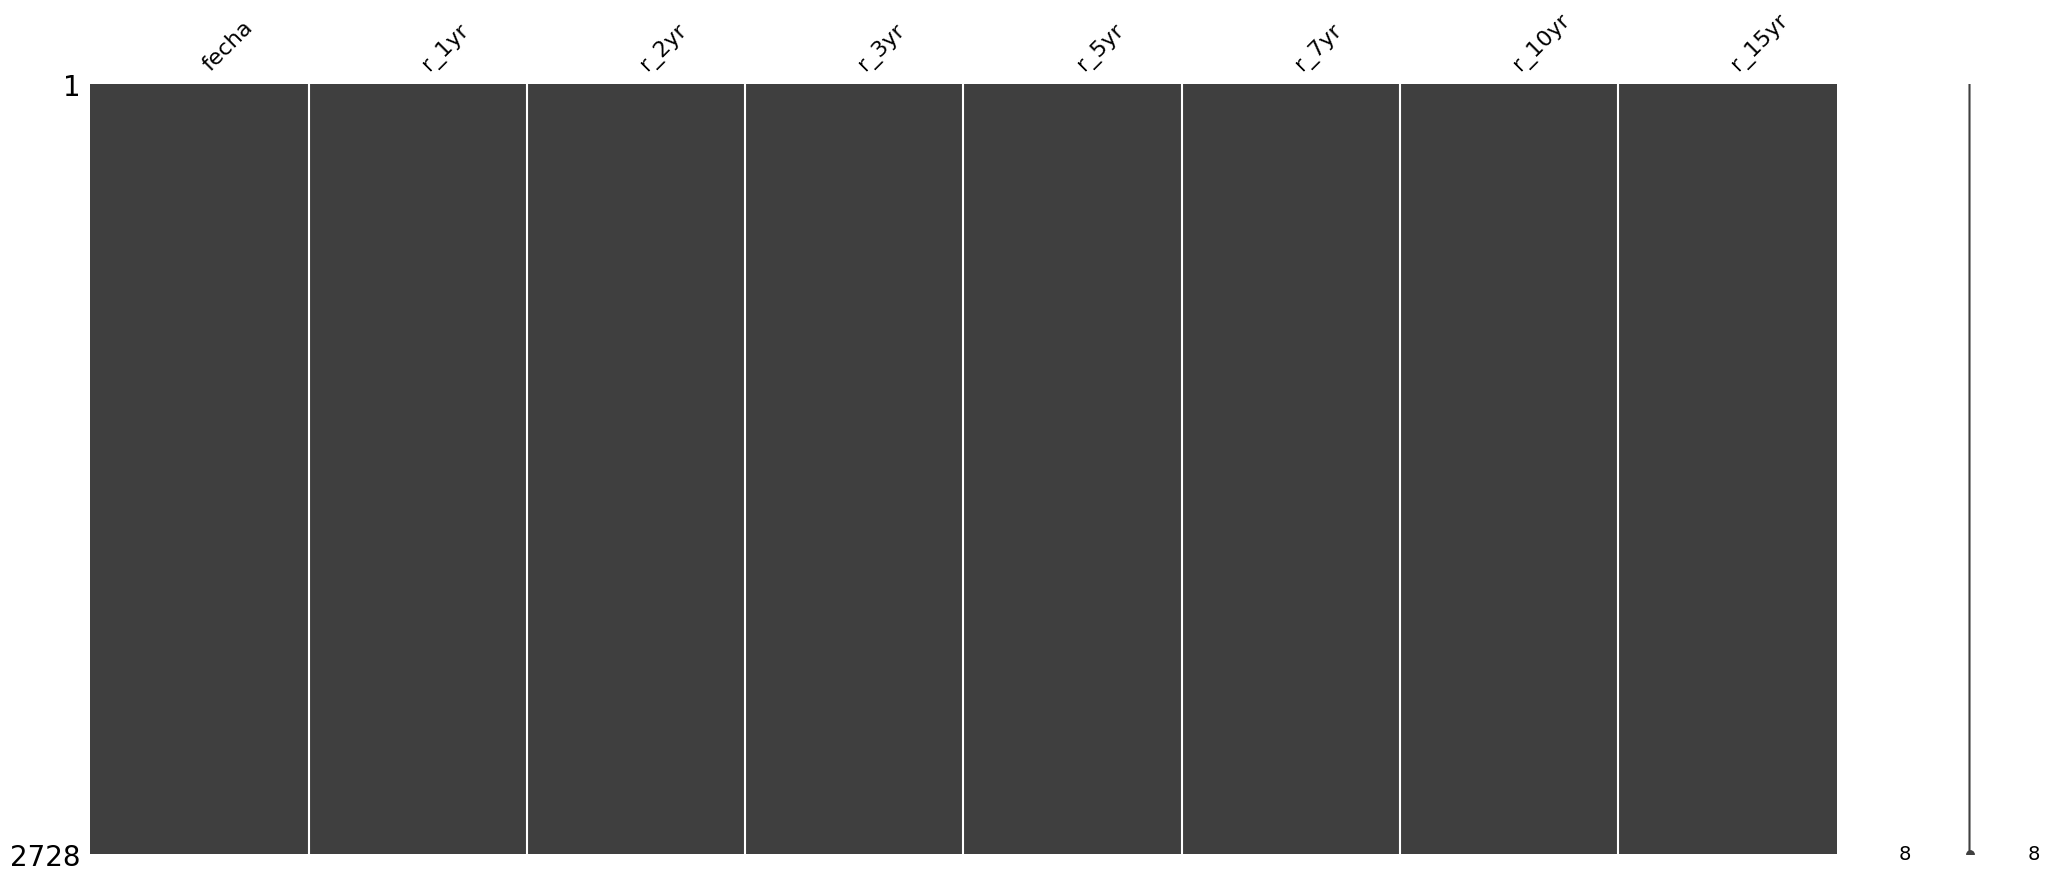

In [42]:
# por practividad, se eliminarán las filas con datos faltantes
df = df.dropna()
miss.matrix(df)

In [46]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2728 entries, 0 to 2734
Data columns (total 8 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   fecha   2728 non-null   object 
 1   r_1yr   2728 non-null   float64
 2   r_2yr   2728 non-null   float64
 3   r_3yr   2728 non-null   float64
 4   r_5yr   2728 non-null   float64
 5   r_7yr   2728 non-null   float64
 6   r_10yr  2728 non-null   float64
 7   r_15yr  2728 non-null   float64
dtypes: float64(7), object(1)
memory usage: 191.8+ KB


# Dinamica de los rendimientos a lo largo del tiempo

In [48]:
# 1. Definir vencimientos (Eje X) según la base actual
vencimientos = [1, 2, 3, 5, 7, 10, 15]
columnas_bonos = ["r_1yr", "r_2yr", "r_3yr", "r_5yr", "r_7yr", "r_10yr", "r_15yr"]

# 2. Asegurar formato de fecha y ordenar
df_plot = df.copy()
df_plot["fecha"] = pd.to_datetime(df_plot["fecha"], errors="coerce")
df_plot = df_plot.dropna(subset=["fecha"]).sort_values("fecha")

# 3. Tomar una muestra temporal para que el gráfico sea más legible
step = 1
fechas = df_plot["fecha"].iloc[::step]
matriz_rendimientos = df_plot[columnas_bonos].iloc[::step].values

# 4. Crear la figura 3D
fig = go.Figure(data=[go.Surface(
    z=matriz_rendimientos,
    x=vencimientos,
    y=fechas,
    colorscale="Viridis",
    colorbar_title="Rendimiento (%)"
 )])

# 5. Configurar diseño
fig.update_layout(
    title="Evolución de la Curva de Rendimientos (TES Colombia)",
    autosize=True,
    width=1000,
    height=800,
    margin=dict(l=65, r=50, b=65, t=90),
    scene=dict(
        xaxis_title="Vencimiento (Años)",
        yaxis_title="Fecha",
        zaxis_title="Rendimiento (%)",
        camera=dict(eye=dict(x=1.5, y=1.5, z=0.8)),
    ),
)

fig.show()

In [50]:
# gráfico animado de rendimientos observados por fecha (sin ajuste NS/NSS)
import pandas as pd
import numpy as np
import plotly.graph_objects as go

# vencimientos disponibles en la base actual
maturity_map = {
    1: "r_1yr",
    2: "r_2yr",
    3: "r_3yr",
    5: "r_5yr",
    7: "r_7yr",
    10: "r_10yr",
    15: "r_15yr",
}
maturities = np.array(list(maturity_map.keys()))
yield_cols = [maturity_map[m] for m in maturities]

# preparar datos
df_points = df[["fecha"] + yield_cols].copy()
df_points["fecha"] = pd.to_datetime(df_points["fecha"], errors="coerce")
df_points = df_points.dropna(subset=["fecha"]).sort_values("fecha").reset_index(drop=True)

# reducir cantidad de frames para mantener fluidez
date_step = 1
df_points = df_points.iloc[::date_step].reset_index(drop=True)

max_frames = 250
if len(df_points) > max_frames:
    idx = np.linspace(0, len(df_points) - 1, max_frames, dtype=int)
    df_points = df_points.iloc[idx].reset_index(drop=True)

if df_points.empty:
    raise ValueError("No hay filas válidas para construir el gráfico de rendimientos.")

frames = []
for _, row in df_points.iterrows():
    yvals = row[yield_cols].astype(float).values
    valid_mask = ~np.isnan(yvals)

    x_obs = maturities[valid_mask]
    y_obs = yvals[valid_mask]

    frame_name = row["fecha"].strftime("%Y-%m-%d")

    frames.append(
        go.Frame(
            name=frame_name,
            data=[
                go.Scatter(
                    x=x_obs,
                    y=y_obs,
                    mode="lines+markers",
                    name="Curva observada",
                    line=dict(width=2.4, color="#1f77b4", shape="spline", smoothing=0.55),
                    marker=dict(size=8, color="#1f77b4", line=dict(width=1, color="#ffffff")),
                )
            ],
        )
    )

# figura base con el primer frame
fig = go.Figure(data=frames[0].data, frames=frames)

slider_steps = [
    {
        "args": [[fr.name], {"frame": {"duration": 0, "redraw": True}, "mode": "immediate"}],
        "label": fr.name,
        "method": "animate",
    }
    for fr in frames
]

# rango dinámico del eje y
ymin = float(np.nanmin(df_points[yield_cols].values))
ymax = float(np.nanmax(df_points[yield_cols].values))
pad = (ymax - ymin) * 0.08 if ymax > ymin else 0.5

fig.update_layout(
    title=f"Curva de Rendimientos Observada por Fecha ({frames[0].name})",
    xaxis_title="Vencimiento (años)",
    yaxis_title="Rendimiento (%)",
    xaxis=dict(tickmode="array", tickvals=maturities),
    yaxis=dict(range=[ymin - pad, ymax + pad]),
    template="plotly_white",
    hovermode="x unified",
    sliders=[
        {
            "active": 0,
            "currentvalue": {"prefix": "Fecha: "},
            "pad": {"t": 40},
            "steps": slider_steps,
        }
    ],
    updatemenus=[
        {
            "type": "buttons",
            "showactive": False,
            "x": 1.0,
            "y": 1.15,
            "xanchor": "right",
            "yanchor": "top",
            "buttons": [
                {
                    "label": "Play",
                    "method": "animate",
                    "args": [
                        None,
                        {
                            "frame": {"duration": 140, "redraw": True},
                            "fromcurrent": True,
                            "transition": {"duration": 0},
                        },
                    ],
                },
                {
                    "label": "Pause",
                    "method": "animate",
                    "args": [[None], {"frame": {"duration": 0, "redraw": False}, "mode": "immediate"}],
                },
            ],
        }
    ],
)

fig.show()

In [47]:
# exportar dataset limpio
df.to_csv(r"C:\\Users\\ADMON\\Documents\\Universidad\\Proyecto KMJ\\codigo\\TES_colombia\\curvas_panel_historico_limpio.csv", index=False)